# LightGBM Learning Notebook


This notebook shows how to use **LightGBM** for classification, regression,
feature importance, and common training options.

faster than XGBoost on large datasets

uses leaf-wise tree growth

efficient memory usage

Used for:

large datasets

high dimensional data

Kaggle competitions

## Jupyter setup

```bash
pip install lightgbm scikit-learn pandas numpy matplotlib jupyter
jupyter notebook
```

## Imports

In [1]:
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
print("lightgbm version:", lgb.__version__)

lightgbm version: 4.6.0


## LGBMClassifier

In [2]:
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target
)
clf = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/opt/homebrew/anaconda3/envs/mlenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Feature importance

worst texture           507
worst concave points    498
worst symmetry          283
worst perimeter         255
mean concave points     238
mean texture            235
area error              227
worst radius            206
worst smoothness        182
worst area              174
dtype: int32


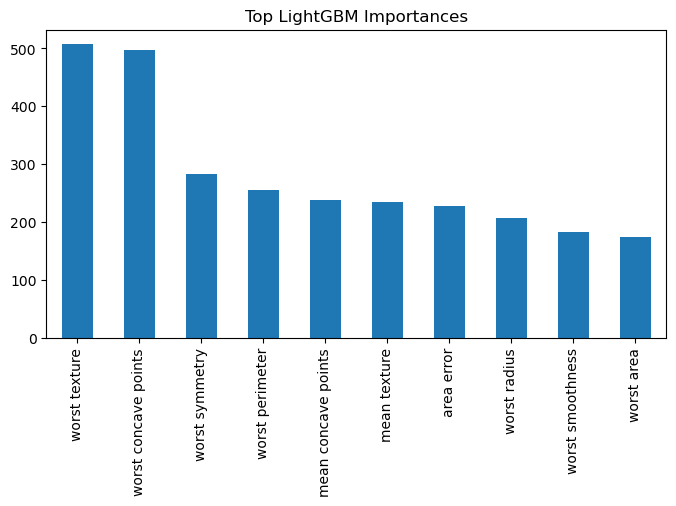

In [3]:
imp = pd.Series(clf.feature_importances_, index=data.feature_names).sort_values(ascending=False)
print(imp.head(10))
imp.head(10).plot(kind="bar", figsize=(8,4), title="Top LightGBM Importances")
plt.show()

## LGBMRegressor

In [4]:
housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42
)
reg = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=42)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
print("RMSE:", mean_squared_error(y_test, pred, squared=False))
print("R2:", r2_score(y_test, pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000448 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


/opt/homebrew/anaconda3/envs/mlenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


TypeError: got an unexpected keyword argument 'squared'

## Native Dataset API

In [5]:
train_ds = lgb.Dataset(X_train, label=y_train)
print(train_ds)

## Useful classes and methods

In [6]:
reference = {
    "Models": ["LGBMClassifier", "LGBMRegressor", "Dataset"],
    "Methods": ["fit", "predict", "predict_proba", "feature_importances_"],
    "Key params": ["n_estimators", "learning_rate", "num_leaves", "max_depth", "subsample", "colsample_bytree"]
}
for k, v in reference.items():
    print("\n" + k + ":")
    print(", ".join(v))


Models:
LGBMClassifier, LGBMRegressor, Dataset

Methods:
fit, predict, predict_proba, feature_importances_

Key params:
n_estimators, learning_rate, num_leaves, max_depth, subsample, colsample_bytree
